# Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from mlxtend.plotting import plot_decision_regions

import warnings
warnings.filterwarnings('ignore')

# Create a dataframe

In [2]:
df = pd.DataFrame()

df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


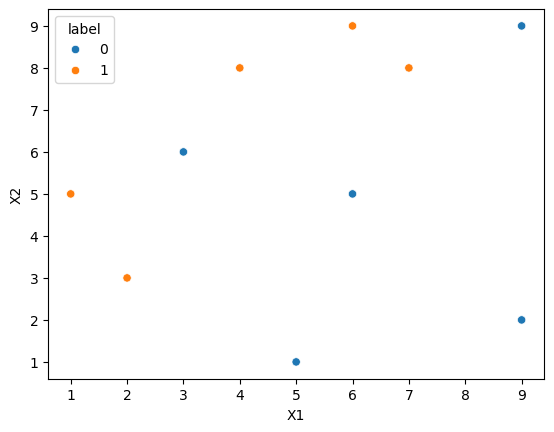

In [3]:
sns.scatterplot(data=df, x=df['X1'], y=df['X2'], hue=df['label']);

# Step 1 - Assign weights for each row/data point

In [4]:
df['weights'] = 1/df.shape[0]
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


# Step 2 - Train a Decision Stump and Predict on training data

In [5]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [6]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, 2].values

In [7]:
dt1.fit(X, y)

DecisionTreeClassifier(max_depth=1)

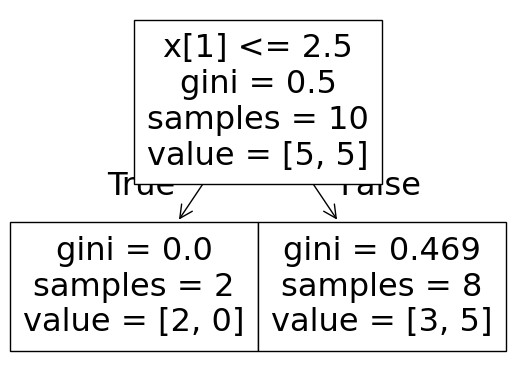

In [8]:
plot_tree(dt1);

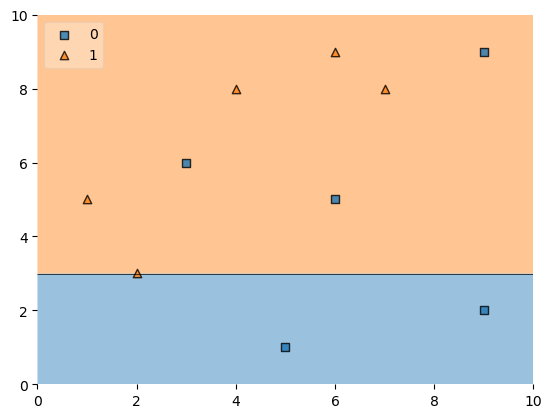

In [9]:
plot_decision_regions(X, y, clf=dt1, legend=2);

In [10]:
df['y_pred'] = dt1.predict(X)
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


# Step 3 - Calculate the model weight

In [11]:
def calculate_model_weight(error):
    return 0.5 * np.log((1-error) / (error))

In [12]:
alpha1 = calculate_model_weight(0.3) # error = 0.1 + 0.1 + 0.1 = 0.3
alpha1

np.float64(0.42364893019360184)

# Step 4 - Update the weights

In [13]:
def update_row_weight(row, alpha=0.423):
    # Correctly classified points
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    # Wrongly classified points
    else:
        return row['weights'] * np.exp(alpha)

In [14]:
df['updated_weights'] = df.apply(update_row_weight, axis=1)
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


* Notice the increase in weights of wrongly predicted rows.

# Step 5 - Upsampling

In [15]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

## Step 5.1 - Normalize the weights

In [16]:
df['normalize_weights'] = df['updated_weights'] / df['updated_weights'].sum()
df

,X1,X2,label,weights,y_pred,updated_weights,normalize_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


## Step 5.2 - Calculate the intervals (range)

In [17]:
df['cumsum_upper'] = np.cumsum(df['normalize_weights'])
df['cumsum_lower'] = df['cumsum_upper'] - df['normalize_weights']

In [18]:
# Reorder the colums
df[['X1', 'X2', 'label', 'weights', 'y_pred', 'updated_weights', 'cumsum_lower', 'cumsum_upper']]
df

,X1,X2,label,weights,y_pred,updated_weights,normalize_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,1,0.152653,0.166559,0.309508,0.142950
3,4,8,1,0.1,1,0.065508,0.071475,0.380983,0.309508
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,1,0.065508,0.071475,0.523933,0.452458
6,6,5,0,0.1,1,0.152653,0.166559,0.690492,0.523933
7,7,8,1,0.1,1,0.065508,0.071475,0.761967,0.690492
8,9,9,0,0.1,1,0.152653,0.166559,0.928525,0.761967
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


# Step 6 - Create new dataset (upsampled)

In [19]:
def create_new_dataset(df):
    indices = []
    for i in range(df.shape[0]):
        a = np.random.random()
        for idx, row in df.iterrows():
            # See which points lie in the range
            if row['cumsum_lower'] < a and row['cumsum_upper'] > a:
                indices.append(idx)
    return indices

In [20]:
index_values = create_new_dataset(df)
index_values

[5, 9, 9, 2, 1, 5, 9, 1, 9, 9]

# Second Dataset

In [21]:
df2 = df.iloc[index_values, [0, 1, 2, 3]] # Select the first four columns
df2

,X1,X2,label,weights
5,6,9,1,0.1
9,9,2,0,0.1
9,9,2,0,0.1
2,3,6,0,0.1
1,2,3,1,0.1
5,6,9,1,0.1
9,9,2,0,0.1
1,2,3,1,0.1
9,9,2,0,0.1
9,9,2,0,0.1


## Step 2 - Train a Decision Stump and Predict on training data

In [22]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [23]:
X = df2.iloc[:, 0:2].values
y = df2.iloc[:, 2].values

In [24]:
dt2.fit(X, y)

DecisionTreeClassifier(max_depth=1)

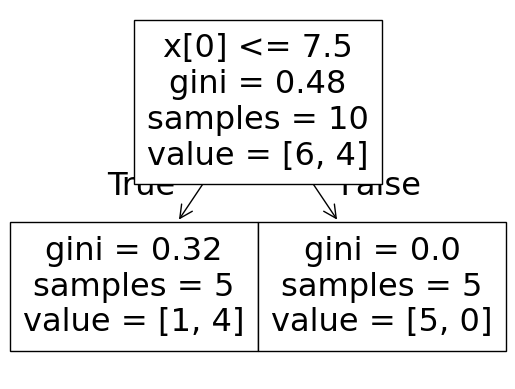

In [25]:
plot_tree(dt2);

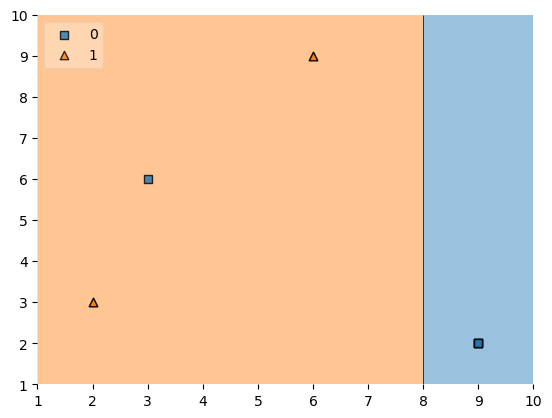

In [26]:
plot_decision_regions(X, y, clf=dt2, legend=2);

In [27]:
df2['y_pred'] = dt2.predict(X)
df2

,X1,X2,label,weights,y_pred
5,6,9,1,0.1,1
9,9,2,0,0.1,0
9,9,2,0,0.1,0
2,3,6,0,0.1,1
1,2,3,1,0.1,1
5,6,9,1,0.1,1
9,9,2,0,0.1,0
1,2,3,1,0.1,1
9,9,2,0,0.1,0
9,9,2,0,0.1,0


## Step 3 - Calculate model weight

In [28]:
alpha2 = calculate_model_weight(0.1) # error = 0.1
alpha2

np.float64(1.0986122886681098)

## Step 4 - Update the weights

In [29]:
def update_row_weight(row, alpha=0.693):
    # Correctly classified points
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    # Wrongly classified points
    else:
        return row['weights'] * np.exp(alpha)

In [30]:
df2['updated_weights'] = df2.apply(update_row_weight, axis=1)
df2

,X1,X2,label,weights,y_pred,updated_weights
5,6,9,1,0.1,1,0.050007
9,9,2,0,0.1,0,0.050007
9,9,2,0,0.1,0,0.050007
2,3,6,0,0.1,1,0.199971
1,2,3,1,0.1,1,0.050007
5,6,9,1,0.1,1,0.050007
9,9,2,0,0.1,0,0.050007
1,2,3,1,0.1,1,0.050007
9,9,2,0,0.1,0,0.050007
9,9,2,0,0.1,0,0.050007


## Step 5 - Upsampling

### Step 5.1 - Normalize the weights

In [31]:
df2['normalize_weights'] = df2['updated_weights'] / df2['updated_weights'].sum()
df2

,X1,X2,label,weights,y_pred,updated_weights,normalize_weights
5,6,9,1,0.1,1,0.050007,0.07693
9,9,2,0,0.1,0,0.050007,0.07693
9,9,2,0,0.1,0,0.050007,0.07693
2,3,6,0,0.1,1,0.199971,0.30763
1,2,3,1,0.1,1,0.050007,0.07693
5,6,9,1,0.1,1,0.050007,0.07693
9,9,2,0,0.1,0,0.050007,0.07693
1,2,3,1,0.1,1,0.050007,0.07693
9,9,2,0,0.1,0,0.050007,0.07693
9,9,2,0,0.1,0,0.050007,0.07693


### Step 5.2 - Calculate the intervals (range)

In [32]:
df2['cumsum_upper'] = np.cumsum(df2['normalize_weights'])
df2['cumsum_lower'] = df2['cumsum_upper'] - df2['normalize_weights']

In [33]:
# Reorder the colums
df2[['X1', 'X2', 'label', 'weights', 'y_pred', 'updated_weights', 'cumsum_lower', 'cumsum_upper']]
df2

,X1,X2,label,weights,y_pred,updated_weights,normalize_weights,cumsum_upper,cumsum_lower
5,6,9,1,0.1,1,0.050007,0.07693,0.07693,0.00000
9,9,2,0,0.1,0,0.050007,0.07693,0.15386,0.07693
9,9,2,0,0.1,0,0.050007,0.07693,0.23079,0.15386
2,3,6,0,0.1,1,0.199971,0.30763,0.53842,0.23079
1,2,3,1,0.1,1,0.050007,0.07693,0.61535,0.53842
5,6,9,1,0.1,1,0.050007,0.07693,0.69228,0.61535
9,9,2,0,0.1,0,0.050007,0.07693,0.76921,0.69228
1,2,3,1,0.1,1,0.050007,0.07693,0.84614,0.76921
9,9,2,0,0.1,0,0.050007,0.07693,0.92307,0.84614
9,9,2,0,0.1,0,0.050007,0.07693,1.00000,0.92307


## Step 6 - Create new dataset (upsampled)

In [34]:
index_values = create_new_dataset(df2)
index_values

[1, 9, 1, 1, 9, 5, 9, 9, 2, 9]

# Prediction

In [35]:
query = np.array([1, 5]).reshape(1, 2)

## First model

In [36]:
dt1.predict(query)

array([1])

## Second model

In [37]:
dt2.predict(query)

array([1])

## Model Prediction

In [38]:
alpha1 * 1 + alpha2 * 1

np.float64(1.5222612188617117)

In [39]:
np.sign(0.423)

np.float64(1.0)

* Final prediction is label 1.